# **Evaluating Chromatin Accessibility-Aware and CRISPRi-Specific Scores for CRISPRi Off-Target Activity Prediction**
### Owen Yu, Princeton Class of 2027, Advisor: Yuri Pritykin

---



CRISPR interference (CRISPRi) is a powerful method for gene repression that utilizes a dead Cas9 (dCas9) to bind to a target sequence and subsequently block transcription without cutting DNA. However, associated with the technology is the issue of off-target binding, which occurs when the guide RNA (gRNA) directs the dCas9 complex to a similar DNA sequence to the target.Off-target effects are difficult to interpret in CRISPRi experiments due to the fact that the binding of dCas9 to an off-target site will not result in a permanent genetic edit. This results in prolonged occupancy at accessible off-target sites, which reduces the available concentration of CRISPRi at the intended primary target.

This notebook introduces a CRISPRi off-target scoring technique that penalizes gRNAs based on chromatin accessibility at off-target sites, capturing the dilution of dCas9 concentration that reduces on-target efficacy.



---



**If Session Restarts:**
Note that if the session restarts, all variables will be lost and must be reloaded. If you are attempting to only run the figures based on pre-computed values, then run the following sections to directly restore all data without re-running the time-intensive enumeration or score computation steps:

1. **Section 1**: Run Entire Section
2. **Section 2**: Run Entire Section
3. **Section 6**: Run Entire Section

##1. Environment Setup
First, we install the libraries and tools that we will use for the analysis. This includes GuideScan2, which is a tool for enumeration of CRISPR off-target sites using a prebuilt genome index.

In [27]:
import tempfile
import subprocess
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import time
from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score, roc_curve

!pip install pyBigWig -q
import pyBigWig

from google.colab import drive
drive.mount('/content/drive')

# Paths
GUIDESCAN_PATH = "./guidescan-cli/build/bin/guidescan"
INDEX_PATH = "/tmp/hg38.index"
DATA_PATH = "/content/drive/MyDrive/IndependentWork/Data/"

print("Setup complete")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete


In [28]:
# Build GuideScan2 (run once per session)
!apt-get install -y cmake g++ zlib1g-dev -q
!git clone https://github.com/pritykinlab/guidescan-cli
!cd guidescan-cli && mkdir build && cd build && cmake .. && make -j4
!./guidescan-cli/build/bin/guidescan --help


# Copy hg38 index to local storage
base = f"{DATA_PATH}hg38/GCF_000001405.39_GRCh38.p13_genomic.fna.index"
for ext in ['.forward', '.reverse', '.gs']:
    if not os.path.exists(f"/tmp/hg38.index{ext}"):
        print(f"  Copying {ext}...")
        os.system(f"cp '{base}{ext}' /tmp/hg38.index{ext}")

Reading package lists...
Building dependency tree...
Reading state information...
g++ is already the newest version (4:11.2.0-1ubuntu1).
cmake is already the newest version (3.22.1-1ubuntu1.22.04.2).
zlib1g-dev is already the newest version (1:1.2.11.dfsg-2ubuntu9.2).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
fatal: destination path 'guidescan-cli' already exists and is not an empty directory.
mkdir: cannot create directory ‘build’: File exists
Guidescan all-in-one interface.

Usage: ./guidescan-cli/build/bin/guidescan [OPTIONS] SUBCOMMAND

Options:
  -h,--help                   Print this help message and exit
  --version                   Display program version information and exit

Subcommands:
  enumerate                   Enumerates off-targets against a reference.
  index                       Builds an genomic index over a FASTA file.
  download                    Downloads GuideScan data over HTTP.



## 2. Load Data
### 2.1 Exploring cleaned tiling screen dataset from the Katsano study (Srikanth et al., 2026)
The study from Srikanth et al., 2026 developed Katsano, an optimized genome-wide CRISPRi library, by conducting large-scale tiling screens to systematically evaluate guide efficacy, repressor domain configurations, and off-target behavior. A key output of their work was the identification of "promiscuous" gRNAs, those whose phenotypic effects are driven by off-target binding rather than on-target repression, which they linked to PAM-rich seed sequences and high genomic match counts. We will use their cleaned tiling screen dataset, which contains per-guide phenotypic z-scores and promiscuity labels, as our ground truth for evaluating whether our dilution-aware score can predict guide underperformance. Importantly, while Srikanth et al. used ATAC-seq data to characterize chromatin accessibility at on-target sites, they did not model the accessibility of off-target sites. This is the gap our scoring mechanism aims to address.

In [29]:
df = pd.read_csv("/content/drive/MyDrive/IndependentWork/Data/CleanedOffTargetTiling.csv")
print(df.shape)
print(df.columns.tolist())
print(df.head())

(33231, 20)
['Target Gene Symbol', 'Category', 'TSS Position', 'sgRNA Sequence', 'sgRNA Context Sequence', 'On-Target Efficacy Score', "sgRNA 'Cut' Site TSS Offset", 'avg_lfc_A549_Zim3', 'z_scored_avg_lfc_A549_Zim3', 'avg_lfc_A549_Kox1', 'z_scored_avg_lfc_A549_Kox1', 'avg_lfc_HCT116_Zim3', 'z_scored_avg_lfc_HCT116_Zim3', 'avg_lfc_HCT116_Kox1', 'z_scored_avg_lfc_HCT116_Kox1', 'avg_zscore', 'gene_avg_zscore', 'Unnamed: 17', 'label', 'promiscuous']
  Target Gene Symbol       Category  TSS Position        sgRNA Sequence  \
0              OR6K6  Non-essential   158754721.0  AAAAAAAAAAGGTCATTCAG   
1             CYP7A1  Non-essential    58500163.0  AAAAAAAAAGTGGTAGTAAC   
2               IL22  Non-essential    68253604.0  AAAAAAAAGTCAGTATCCTG   
3            DEFB126  Non-essential      142591.0  AAAAAAACAAAAGTGAAATG   
4               IL22  Non-essential    68253604.0  AAAAAAAGTCAGTATCCTGG   

           sgRNA Context Sequence  On-Target Efficacy Score  \
0  CTAGAAAAAAAAAAGGTCATTCAGGGGTCC   

/tmp/ipykernel_100002/2671060580.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/IndependentWork/Data/CleanedOffTargetTiling.csv")


In [30]:
# How many promiscuous vs nonpromiscuous guides?
print(df['promiscuous'].value_counts())

# Distribution of avg_zscore
print(df['avg_zscore'].describe())

# How many unique genes?
print(f"Unique genes: {df['Target Gene Symbol'].nunique()}")

# Quick look at promiscuous guides
promiscuous = df[df['promiscuous'] == True]
nonpromiscuous = df[df['promiscuous'] == False]

print(f"\nPromiscuous guides: {len(promiscuous)}")
print(f"Nonpromiscuous guides: {len(nonpromiscuous)}")

print(f"\nAvg zscore for promiscuous: {promiscuous['avg_zscore'].mean():.3f}")
print(f"Avg zscore for nonpromiscuous: {nonpromiscuous['avg_zscore'].mean():.3f}")

print(df['sgRNA Sequence'].head(10))
print(f"Total unique sequences: {df['sgRNA Sequence'].nunique()}")

promiscuous
False    31754
True      1477
Name: count, dtype: int64
count    33231.000000
mean        -0.022791
std          1.183144
min         -9.281836
25%         -0.198467
50%          0.168254
75%          0.510217
max          5.388987
Name: avg_zscore, dtype: float64
Unique genes: 1145

Promiscuous guides: 1477
Nonpromiscuous guides: 31754

Avg zscore for promiscuous: -4.824
Avg zscore for nonpromiscuous: 0.201
0    AAAAAAAAAAGGTCATTCAG
1    AAAAAAAAAGTGGTAGTAAC
2    AAAAAAAAGTCAGTATCCTG
3    AAAAAAACAAAAGTGAAATG
4    AAAAAAAGTCAGTATCCTGG
5    AAAAAACAAGAATAGTCCTG
6    AAAAAAGAACTCCTTTATCA
7    AAAAAAGAGGCACAGACTAC
8    AAAAAAGGAATAACAGATAC
9    AAAAAAGTACAACTATGGCA
Name: sgRNA Sequence, dtype: object
Total unique sequences: 33231


We will analyze the distribution of avg_zscore by promiscuity label per gRNA.

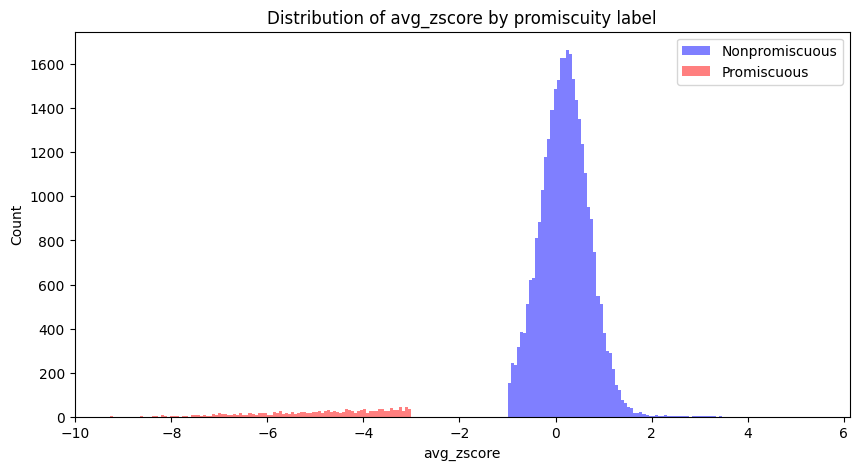

In [31]:
plt.figure(figsize=(10, 5))
plt.hist(nonpromiscuous['avg_zscore'], bins=100, alpha=0.5, label='Nonpromiscuous', color='blue')
plt.hist(promiscuous['avg_zscore'], bins=100, alpha=0.5, label='Promiscuous', color='red')
plt.xlabel('avg_zscore')
plt.ylabel('Count')
plt.title('Distribution of avg_zscore by promiscuity label')
plt.legend()
plt.show()

The histogram confirms clear separation between promiscuous (avg_zscore ≈ -4.8) and nonpromiscuous (avg_zscore ≈ 0.2) guides, validating the use of avg_zscore as a continuous ground truth.

In [32]:
# Drop rows with missing values
df_clean = df.dropna(subset=[
    'On-Target Efficacy Score',
    "sgRNA 'Cut' Site TSS Offset",
    'avg_zscore'
])

print(f"After cleaning: {len(df_clean)} gRNAs (dropped {len(df) - len(df_clean)} NaN rows)")
print(f"Promiscuous: {(df_clean['promiscuous']==True).sum()}")
print(f"Nonpromiscuous: {(df_clean['promiscuous']==False).sum()}")

After cleaning: 32275 gRNAs (dropped 956 NaN rows)
Promiscuous: 1472
Nonpromiscuous: 30803


### 2.2 ATAC-seq Chromatin Accessibility Data
ATAC-seq peak files were downloaded from ENCODE for A549 and HCT116, the same cell lines used in the Katsano screens.


In [33]:
%%script true

# Skip cell when already downloaded to Google Drive

# Download A549 and HCT116 ATAC data directly to Google Drive
!wget "https://www.encodeproject.org/files/ENCFF808YMI/@@download/ENCFF808YMI.bigBed" -O "/content/drive/MyDrive/IndependentWork/Data/A549_ATAC.bigBed"

!wget "https://www.encodeproject.org/files/ENCFF068PVP/@@download/ENCFF068PVP.bigBed" -O "/content/drive/MyDrive/IndependentWork/Data/HCT116_ATAC.bigBed"

# Verify the download worked
print("A549:", os.path.getsize("/content/drive/MyDrive/IndependentWork/Data/A549_ATAC.bigBed"))
print("HCT116:", os.path.getsize("/content/drive/MyDrive/IndependentWork/Data/HCT116_ATAC.bigBed"))

In [34]:
def load_peaks_to_dict(atac_file):
    """Load all peaks from bigBed into dict of {chrom: numpy array of (start, end)}."""
    peaks = {}
    for chrom in atac_file.chroms().keys():
        try:
            entries = atac_file.entries(chrom, 0, atac_file.chroms()[chrom])
            if entries:
                peaks[chrom] = np.array([(e[0], e[1]) for e in entries])
        except:
            pass
    return peaks

a549_atac = pyBigWig.open(f"{DATA_PATH}A549_ATAC.bigBed")
hct116_atac = pyBigWig.open(f"{DATA_PATH}HCT116_ATAC.bigBed")

print("Loading A549 ATAC peaks")
a549_peaks = load_peaks_to_dict(a549_atac)
print(f"A549: {sum(len(v) for v in a549_peaks.values())} peaks")

print("Loading HCT116 ATAC peaks")
hct116_peaks = load_peaks_to_dict(hct116_atac)
print(f"HCT116: {sum(len(v) for v in hct116_peaks.values())} peaks")

# GuideScan2 uses NCBI accession names, so map to chr names for ATAC lookup
acc_to_chr = {
    'NC_000001.11': 'chr1',  'NC_000002.12': 'chr2',  'NC_000003.12': 'chr3',
    'NC_000004.12': 'chr4',  'NC_000005.10': 'chr5',  'NC_000006.12': 'chr6',
    'NC_000007.14': 'chr7',  'NC_000008.11': 'chr8',  'NC_000009.12': 'chr9',
    'NC_000010.11': 'chr10', 'NC_000011.10': 'chr11', 'NC_000012.12': 'chr12',
    'NC_000013.11': 'chr13', 'NC_000014.9':  'chr14', 'NC_000015.10': 'chr15',
    'NC_000016.10': 'chr16', 'NC_000017.11': 'chr17', 'NC_000018.10': 'chr18',
    'NC_000019.10': 'chr19', 'NC_000020.11': 'chr20', 'NC_000021.9':  'chr21',
    'NC_000022.11': 'chr22', 'NC_000023.11': 'chrX',  'NC_000024.10': 'chrY',
}

Loading A549 ATAC peaks...
A549: 278564 peaks
Loading HCT116 ATAC peaks...
HCT116: 218413 peaks


## 3. Helper Functions
### 3.1 Vectorized ATAC Accessibility Lookup
For each off-target site, we check whether its genomic position falls within an ATAC-seq peak using a binary search (`np.searchsorted`) against a pre-sorted peak arrays.

In [35]:
def is_in_peaks_vectorized(chroms, positions, peaks_dict):
    """Check chromatin accessibility for arrays of (chrom, position) pairs."""
    result = np.zeros(len(positions), dtype=np.int8)
    df_temp = pd.DataFrame({'chrom': chroms, 'pos': positions, 'idx': np.arange(len(positions))})
    for chrom, group in df_temp.groupby('chrom'):
        if chrom not in peaks_dict:
            continue
        peaks = peaks_dict[chrom]
        starts, ends = peaks[:, 0], peaks[:, 1]
        pos_array = group['pos'].values
        insert_idx = np.searchsorted(starts, pos_array, side='right') - 1
        valid = insert_idx >= 0
        in_peak = np.zeros(len(pos_array), dtype=np.int8)
        in_peak[valid] = (pos_array[valid] < ends[insert_idx[valid]]).astype(np.int8)
        result[group['idx'].values] = in_peak
    return result

### 3.2 Per-Off-Target Scoring Functions


In [36]:
def compute_rohatgi_weight(guide_seq, match_seq):
    """Per-off-target binding stability: seed_match_length x GC_content (PAM-proximal 12bp)."""
    guide = str(guide_seq)[:20].upper()
    match = str(match_seq)[:20].upper()
    if len(guide) < 20 or len(match) < 20:
        return 0.0
    seed_match_len = 0
    for i in range(19, -1, -1):
        if guide[i] == match[i]:
            seed_match_len += 1
        else:
            break
    seed_region = match[8:20]
    gc_content = (seed_region.count('G') + seed_region.count('C')) / 12
    return seed_match_len * gc_content


def compute_katsano_seed_score(seq):
    """Count GG dinucleotides in PAM-proximal 12bp seed region."""
    seed = seq[-12:]
    return sum(1 for i in range(len(seed)-1) if seed[i:i+2] == 'GG')


# Load CFD mismatch and PAM score matrices
!wget "https://github.com/maximilianh/crisporWebsite/raw/master/CFD_Scoring/mismatch_score.pkl" \
    -O mismatch_score.pkl -q
!wget "https://github.com/maximilianh/crisporWebsite/raw/master/CFD_Scoring/pam_scores.pkl" \
    -O pam_scores.pkl -q

with open("mismatch_score.pkl", "rb") as f:
    mm_scores = pickle.load(f)
with open("pam_scores.pkl", "rb") as f:
    pam_scores = pickle.load(f)

basecomp = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A', 'U': 'A'}

def compute_cfd_per_offtarget(offs_df):
    """CFD score for each off-target row."""
    cfd_scores = []
    for _, row in offs_df.iterrows():
        wt = row['sequence'][:20].upper().replace('T', 'U')
        off = row['match_sequence'][:20].upper().replace('T', 'U')
        pam = row['match_sequence'][21:23].upper() if len(str(row['match_sequence'])) > 21 else 'GG'
        score = 1.0
        for i, (w, o) in enumerate(zip(wt, off)):
            if w != o:
                key = 'r' + w + ':d' + basecomp.get(o, 'A') + ',' + str(i + 1)
                score *= mm_scores.get(key, 0.0)
        score *= pam_scores.get(pam, 0.0)
        cfd_scores.append(score)
    return np.array(cfd_scores)

print("All helper functions defined!")

All helper functions defined!


### 3.3 GuideScan2 Batch Enumeration
GuideScan2 is run as a command line tool across all 32,275 gRNAs in 32 sequential batches of ~1,000 gRNAs each, as the initial implementation took 10+ hours.

In [37]:
def run_all_sequential(dataframe, guidescan_path, index_path, n_chunks=32, mismatches=3):
    """
    Run GuideScan2 off-target enumeration on all guides in sequential batches.
    """
    chunks = np.array_split(dataframe, n_chunks)
    all_results = []
    failed_chunks = []
    total_start = time.time()

    print(f"Processing {len(dataframe)} guides in {n_chunks} chunks at {mismatches} mismatches...")

    for i, chunk in enumerate(chunks):
        if len(chunk) == 0:
            continue

        temp_kmers = f"/tmp/kmers_chunk_{i}.csv"
        temp_output = f"/tmp/output_chunk_{i}.csv"

        with open(temp_kmers, 'w') as f:
            f.write("id,sequence,pam,chromosome,position,sense\n")
            for idx, row in chunk.iterrows():
                f.write(f"guide_{idx},{row['sgRNA Sequence']},NGG,,,+\n")

        cmd = (f"{guidescan_path} enumerate {index_path} -f {temp_kmers} "
               f"--format csv -o {temp_output} --mismatches {mismatches}")
        chunk_start = time.time()
        result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
        chunk_time = time.time() - chunk_start

        if os.path.exists(temp_output) and os.path.getsize(temp_output) > 0:
            try:
                chunk_result = pd.read_csv(temp_output)
                all_results.append(chunk_result)
                elapsed = time.time() - total_start
                remaining = (elapsed / (i + 1)) * (n_chunks - i - 1)
                print(f"  Chunk {i+1}/{n_chunks}: {len(chunk)} guides → "
                      f"{len(chunk_result)} rows in {chunk_time:.0f}s | "
                      f"Elapsed: {elapsed/60:.1f}m | Remaining: ~{remaining/60:.1f}m")
            except Exception as e:
                print(f"  Chunk {i+1}/{n_chunks}: FAILED to read CSV - {e}")
                failed_chunks.append(i)
        else:
            print(f"  Chunk {i+1}/{n_chunks}: FAILED - no output")
            failed_chunks.append(i)

        for f in [temp_kmers, temp_output]:
            if os.path.exists(f): os.remove(f)

    total_time = time.time() - total_start
    print(f"\nTotal time: {total_time/60:.1f} minutes")
    if failed_chunks:
        print(f"WARNING: {len(failed_chunks)} chunks failed: {failed_chunks}")
    return pd.concat(all_results, ignore_index=True)

## 4. Off-Target Enumeration

GuideScan2 is run at both 3 mismatches and 4 mismatches to test whether expanding the search depth improves promiscuity prediction.

In [38]:
%%script true

# Skip if CSV already saved

# Run 3-mismatch enumeration
final_offtargets_df = run_all_sequential(
    df_clean, GUIDESCAN_PATH, INDEX_PATH, n_chunks=32, mismatches=3
)
print(f"3mm: {len(final_offtargets_df)} guide-off-target pairs")
final_offtargets_df.to_csv(f"{DATA_PATH}full_genome_offtargets.csv", index=False)

# Run 4-mismatch enumeration
final_offtargets_4mm = run_all_sequential(
    df_clean, GUIDESCAN_PATH, INDEX_PATH, n_chunks=32, mismatches=4
)
print(f"4mm: {len(final_offtargets_4mm)} guide-off-target pairs")
final_offtargets_4mm.to_csv(f"{DATA_PATH}full_genome_offtargets_4mm.csv", index=False)

## 5. Score Computation

Five scoring methods are computed for each gRNA at 3 mismatches and 4 mismatches. All scores follow the GuideScan2 specificity score framework, where the score is a value between 0 and 1 where a lower scores indicate more predicted off-target activity.

In [39]:
def compute_all_scores(offtargets_df, label=""):
    """Compute all scoring formulations. Returns dict of {score_name: series indexed by guide_id}."""
    print(f"\nComputing scores for {label}...")
    offs = offtargets_df[offtargets_df['match_distance'] > 0].copy()
    offs['chrom'] = offs['match_chrm'].map(acc_to_chr)
    offs = offs.dropna(subset=['chrom'])

    # ATAC accessibility
    print(f"  ATAC lookup for {len(offs):,} off-targets...")
    start = time.time()
    a549_hits   = is_in_peaks_vectorized(offs['chrom'].values, offs['match_position'].values, a549_peaks)
    hct116_hits = is_in_peaks_vectorized(offs['chrom'].values, offs['match_position'].values, hct116_peaks)
    offs['is_atac'] = np.maximum(a549_hits, hct116_hits)
    print(f"  ATAC done in {time.time()-start:.1f}s | "
          f"Accessible: {offs['is_atac'].sum():,} ({offs['is_atac'].mean()*100:.1f}%)")

    offs['inv_dist'] = 1.0 / offs['match_distance']

    # CFD and CACS only for accessible off-targets
    atac_offs = offs[offs['is_atac'] == 1].copy()

    print(f"  Computing CFD for {len(atac_offs):,} accessible off-targets...")
    start = time.time()
    atac_offs['cfd'] = compute_cfd_per_offtarget(atac_offs)
    offs['cfd'] = 0.0
    offs.loc[atac_offs.index, 'cfd'] = atac_offs['cfd'].values
    print(f"  CFD done in {time.time()-start:.1f}s")

    print(f"  Computing CACS weights for {len(atac_offs):,} accessible off-targets...")
    start = time.time()
    atac_offs['cacs_weight'] = atac_offs.apply(
        lambda r: compute_rohatgi_weight(r['sequence'], r['match_sequence']), axis=1
    )
    offs['cacs_weight'] = 0.0
    offs.loc[atac_offs.index, 'cacs_weight'] = atac_offs['cacs_weight'].values
    print(f"  CACS weights done in {time.time()-start:.1f}s")

    grouped = offs.groupby('id')
    return {
        'distance_only': 1 / (1 + grouped['inv_dist'].sum()),
        'atac_only':     1 / (1 + grouped['is_atac'].sum()),
        'dilution':      1 / (1 + grouped.apply(lambda g: (g['inv_dist'] * g['is_atac']).sum())),
        'cfd_atac':      1 / (1 + grouped.apply(lambda g: (g['cfd'] * g['is_atac']).sum())),
        'cacs':          1 / (1 + grouped['cacs_weight'].sum()),
    }


scores_3mm = compute_all_scores(final_offtargets_df,  "3mm")
scores_4mm = compute_all_scores(final_offtargets_4mm, "4mm")


Computing scores for 3mm...
  ATAC lookup for 1,376,919 off-targets...
  ATAC done in 1.0s | Accessible: 111,555 (8.1%)
  Computing CFD for 111,555 accessible off-targets...
  CFD done in 13.7s
  Computing CACS weights for 111,555 accessible off-targets...
  CACS weights done in 1.5s


/tmp/ipykernel_100002/3087365453.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'dilution':      1 / (1 + grouped.apply(lambda g: (g['inv_dist'] * g['is_atac']).sum())),
/tmp/ipykernel_100002/3087365453.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'cfd_atac':      1 / (1 + grouped.apply(lambda g: (g['cfd'] * g['is_atac']).sum())),



Computing scores for 4mm...
  ATAC lookup for 11,184,161 off-targets...
  ATAC done in 5.7s | Accessible: 1,002,466 (9.0%)
  Computing CFD for 1,002,466 accessible off-targets...
  CFD done in 44.3s
  Computing CACS weights for 1,002,466 accessible off-targets...
  CACS weights done in 7.2s


/tmp/ipykernel_100002/3087365453.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'dilution':      1 / (1 + grouped.apply(lambda g: (g['inv_dist'] * g['is_atac']).sum())),
/tmp/ipykernel_100002/3087365453.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'cfd_atac':      1 / (1 + grouped.apply(lambda g: (g['cfd'] * g['is_atac']).sum())),


In [40]:
# Assemble df_scored with all score columns
df_scored = df_clean.copy()
guide_to_idx = {f"guide_{idx}": idx for idx in df_scored.index}

score_columns = {
    'distance_only_score':     scores_3mm['distance_only'],
    'atac_only_score':         scores_3mm['atac_only'],
    'dilution_score':          scores_3mm['dilution'],
    'cfd_atac_score_3mm':      scores_3mm['cfd_atac'],
    'cacs_3mm':                scores_3mm['cacs'],
    'distance_only_score_4mm': scores_4mm['distance_only'],
    'atac_only_score_4mm':     scores_4mm['atac_only'],
    'dilution_score_4mm':      scores_4mm['dilution'],
    'cfd_atac_score_4mm':      scores_4mm['cfd_atac'],
    'cacs_4mm':                scores_4mm['cacs'],
}

for col_name, score_series in score_columns.items():
    df_scored[col_name] = 1.0
    for guide_id, score in score_series.items():
        idx = guide_to_idx.get(guide_id)
        if idx is not None:
            df_scored.at[idx, col_name] = score

# GuideScan2 built-in CFD specificity
guide_specificity = final_offtargets_df.groupby('id')['specificity'].first()
df_scored['guidescan_specificity'] = 1.0
for guide_id, spec in guide_specificity.items():
    idx = guide_to_idx.get(guide_id)
    if idx is not None:
        df_scored.at[idx, 'guidescan_specificity'] = spec

# Katsano seed score
df_scored['katsano_seed_score'] = df_scored['sgRNA Sequence'].apply(compute_katsano_seed_score)

df_scored.to_csv(f"{DATA_PATH}Katsano_Full_All_Scores_Final.csv", index=False)
print(f"df_scored saved: {df_scored.shape}")

df_scored saved: (32275, 32)


## 6. Evaluation and Figures

Each scoring method is evaluated on its ability to separate promiscuous from nonpromiscuous gRNAs using AUROC and Mann-Whitney U. Because lower scores indicate higher predicted promiscuity for all of the scores except the Katsano Seed Score, the negative of each score is used when computing AUROC (except for the Katsano Seed Score, where larger value = more promiscuous).

In [41]:
# Load pre-computed results from disk if you have already done enumeration and score calculations

final_offtargets_df  = pd.read_csv(f"{DATA_PATH}full_genome_offtargets.csv")
final_offtargets_4mm = pd.read_csv(f"{DATA_PATH}full_genome_offtargets_4mm.csv")
df_scored = pd.read_csv(f"{DATA_PATH}Katsano_Full_All_Scores_Final.csv")
guide_to_idx = {f"guide_{idx}": idx for idx in df_scored.index}

print(f"3mm off-targets: {len(final_offtargets_df):,} rows")
print(f"4mm off-targets: {len(final_offtargets_4mm):,} rows")
print(f"df_scored: {df_scored.shape}")

3mm off-targets: 1,553,689 rows
4mm off-targets: 12,126,886 rows
df_scored: (32275, 32)


In [42]:
save_path = f"{DATA_PATH}Figures/"
os.makedirs(save_path, exist_ok=True)

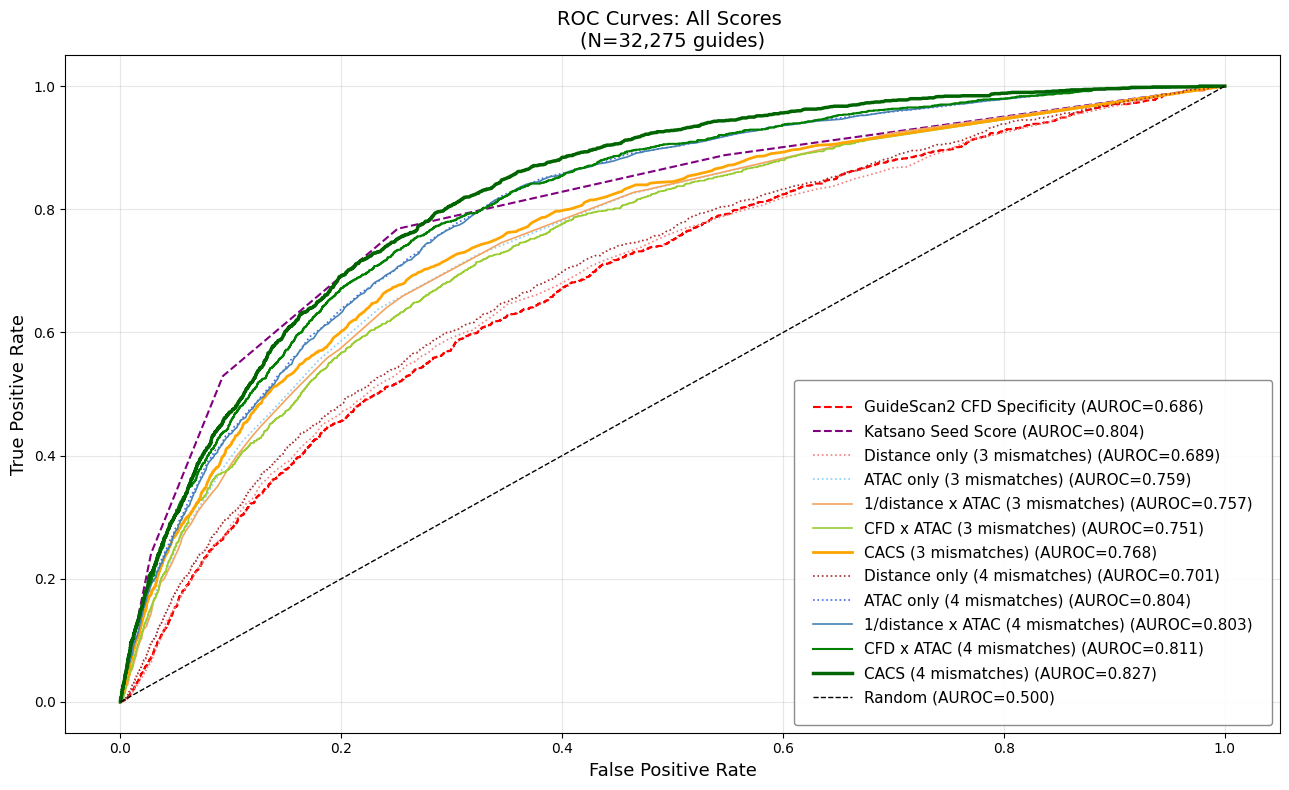

In [43]:
fig, ax = plt.subplots(figsize=(13, 8))

plot_scores = [
    ('GuideScan2 CFD Specificity',        'guidescan_specificity',   True,  'red',          '--', 1.5),
    ('Katsano Seed Score',                 'katsano_seed_score',      False, 'purple',        '--', 1.5),
    ('Distance only (3 mismatches)',       'distance_only_score',     True,  'lightcoral',    ':',  1.2),
    ('ATAC only (3 mismatches)',           'atac_only_score',         True,  'lightskyblue',  ':',  1.2),
    ('1/distance x ATAC (3 mismatches)',   'dilution_score',          True,  'sandybrown',    '-',  1.2),
    ('CFD x ATAC (3 mismatches)',          'cfd_atac_score_3mm',      True,  'yellowgreen',   '-',  1.2),
    ('CACS (3 mismatches)',                'cacs_3mm',                True,  'orange',        '-',  2.0),
    ('Distance only (4 mismatches)',       'distance_only_score_4mm', True,  'brown',         ':',  1.2),
    ('ATAC only (4 mismatches)',           'atac_only_score_4mm',     True,  'royalblue',     ':',  1.2),
    ('1/distance x ATAC (4 mismatches)',   'dilution_score_4mm',      True,  'steelblue',     '-',  1.2),
    ('CFD x ATAC (4 mismatches)',          'cfd_atac_score_4mm',      True,  'green',         '-',  1.5),
    ('CACS (4 mismatches)',             'cacs_4mm',                True,  'darkgreen',     '-',  2.5),
]

for name, col, negate, color, ls, lw in plot_scores:
    data = df_scored.dropna(subset=[col])
    pred = -data[col] if negate else data[col]
    auroc = roc_auc_score(data['promiscuous'], pred)
    fpr, tpr, _ = roc_curve(data['promiscuous'], pred)
    ax.plot(fpr, tpr, label=f'{name} (AUROC={auroc:.3f})', color=color, linestyle=ls, linewidth=lw)

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUROC=0.500)', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves: All Scores \n(N=32,275 guides)', fontsize=14)
ax.legend(loc='lower right', fontsize=11,
          framealpha=0.9,
          edgecolor='gray',
          borderpad=1.3,
          labelspacing=0.6,
          handlelength=2.5,
          handletextpad=0.8,
          markerscale=1.5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(save_path + "figure1_roc_complete.png", dpi=150, bbox_inches='tight')
plt.show()

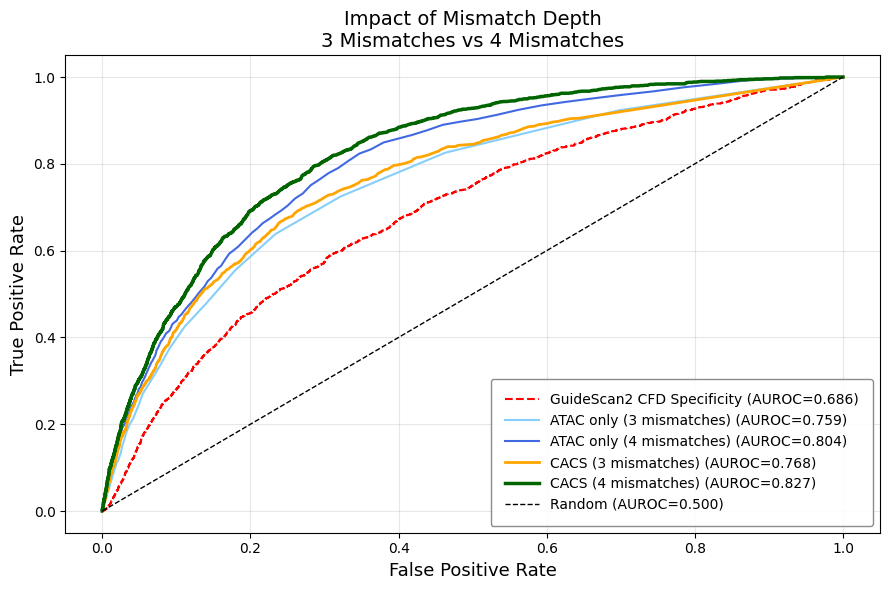

In [44]:
fig, ax = plt.subplots(figsize=(9, 6))

mm_comparison = [
    ('GuideScan2 CFD Specificity', 'guidescan_specificity', True,  'red',          '--', 1.5),
    ('ATAC only (3 mismatches)',    'atac_only_score',       True,  'lightskyblue', '-',  1.5),
    ('ATAC only (4 mismatches)',    'atac_only_score_4mm',   True,  'royalblue',    '-',  1.5),
    ('CACS (3 mismatches)',         'cacs_3mm',              True,  'orange',       '-',  2.0),
    ('CACS (4 mismatches)',      'cacs_4mm',              True,  'darkgreen',    '-',  2.5),
]

for name, col, negate, color, ls, lw in mm_comparison:
    data = df_scored.dropna(subset=[col])
    pred = -data[col] if negate else data[col]
    auroc = roc_auc_score(data['promiscuous'], pred)
    fpr, tpr, _ = roc_curve(data['promiscuous'], pred)
    ax.plot(fpr, tpr, label=f'{name} (AUROC={auroc:.3f})', color=color, linestyle=ls, linewidth=lw)

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUROC=0.500)', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('Impact of Mismatch Depth\n3 Mismatches vs 4 Mismatches', fontsize=14)
ax.legend(loc='lower right', fontsize=10,
          framealpha=0.9,
          edgecolor='gray',
          borderpad=1.0,
          labelspacing=0.5,
          handlelength=2.5,
          handletextpad=0.8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(save_path + "figure2_mismatches.png", dpi=150, bbox_inches='tight')
plt.show()

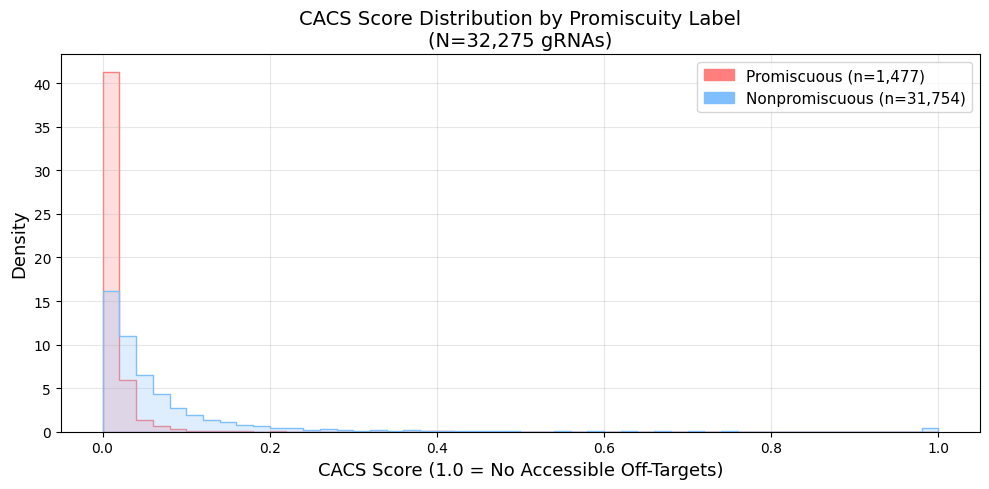


All figures saved to: /content/drive/MyDrive/IndependentWork/Data/Figures/


In [45]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=df_scored, x='cacs_4mm', hue='promiscuous',
    element='step', stat='density', common_norm=False,
    bins=50, ax=ax, palette={True: '#ff7f7f', False: '#7fbfff'}
)
ax.set_xlabel('CACS Score (1.0 = No Accessible Off-Targets)', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title('CACS Score Distribution by Promiscuity Label\n(N=32,275 gRNAs)', fontsize=14)
handles = [
    mpatches.Patch(color='#ff7f7f', label='Promiscuous (n=1,477)'),
    mpatches.Patch(color='#7fbfff', label='Nonpromiscuous (n=31,754)')
]
ax.legend(handles=handles, fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(save_path + "figure3_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAll figures saved to: {save_path}")

In [46]:
all_eval_scores = [
    ('GuideScan2 CFD Specificity',        'guidescan_specificity',   True),
    ('Katsano Seed Score',                 'katsano_seed_score',      False),
    ('Distance only (3 mismatches)',       'distance_only_score',     True),
    ('ATAC only (3 mismatches)',           'atac_only_score',         True),
    ('1/distance x ATAC (3 mismatches)',   'dilution_score',          True),
    ('CFD x ATAC (3 mismatches)',          'cfd_atac_score_3mm',      True),
    ('CACS (3 mismatches)',                'cacs_3mm',                True),
    ('Distance only (4 mismatches)',       'distance_only_score_4mm', True),
    ('ATAC only (4 mismatches)',           'atac_only_score_4mm',     True),
    ('1/distance x ATAC (4 mismatches)',   'dilution_score_4mm',      True),
    ('CFD x ATAC (4 mismatches)',          'cfd_atac_score_4mm',      True),
    ('CACS (4 mismatches)',             'cacs_4mm',                True),
]

print(f"{'Score':<45} {'AUROC':>8} {'p-value':>12}")
print("-" * 67)

for name, col, negate in all_eval_scores:
    data = df_scored.dropna(subset=[col])
    p_group  = data[data['promiscuous'] == True][col]
    np_group = data[data['promiscuous'] == False][col]

    pred = -data[col] if negate else data[col]
    auroc = roc_auc_score(data['promiscuous'], pred)
    _, p = mannwhitneyu(p_group, np_group, alternative='two-sided')

    print(f"{name:<45} {auroc:>8.3f} {p:>12.2e}")

Score                                            AUROC      p-value
-------------------------------------------------------------------
GuideScan2 CFD Specificity                       0.686    8.70e-129
Katsano Seed Score                               0.804     0.00e+00
Distance only (3 mismatches)                     0.689    9.81e-133
ATAC only (3 mismatches)                         0.759    4.87e-258
1/distance x ATAC (3 mismatches)                 0.757    1.04e-253
CFD x ATAC (3 mismatches)                        0.751    2.99e-240
CACS (3 mismatches)                              0.768    3.25e-276
Distance only (4 mismatches)                     0.701    3.49e-150
ATAC only (4 mismatches)                         0.804     0.00e+00
1/distance x ATAC (4 mismatches)                 0.803     0.00e+00
CFD x ATAC (4 mismatches)                        0.811     0.00e+00
CACS (4 mismatches)                              0.827     0.00e+00
